**Initialization**

The notebook has been tested using MI CPU DEL PORTATIL (i5-1035G1)

In [1]:
import os
import random
from matplotlib import pyplot as plt
import cv2
import torch.nn as nn

import numpy as np
import pandas as pd

import snntorch as snn
import torch

# Para crear dataloaders personalizados con TorchVision

from torchvision import datasets, transforms
from torch.utils.data import DataLoader


**Creating train set (NEW, para SNNTorch)**

In [2]:
transform_train = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder("../data_snn_flat/train/", transform=transform_train)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)


print("Total imágenes entrenamiento:", len(train_dataset))

Total imágenes entrenamiento: 155015


In [3]:
# Codigo para comprobar la forma del dataset
"""

for images, labels in train_loader:
    print(images.shape, labels.shape)
    break
"""

'\n\nfor images, labels in train_loader:\n    print(images.shape, labels.shape)\n    break\n'

**Creating the test set (NEW, para SNNTorch)**

In [4]:
transform_test = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])

test_dataset = datasets.ImageFolder("../data_snn_flat/test/", transform=transform_test)

test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Total imágenes test:", len(test_dataset))


Total imágenes test: 30000


In [5]:
# Codigo para comprobar la cantidad de imágenes y los tipos de estas
"""
print(len(train_dataset), len(test_dataset))
print(train_dataset.classes)
"""

'\nprint(len(train_dataset), len(test_dataset))\nprint(train_dataset.classes)\n'

**Mostramos los datos del dataset para ver que las imagenes están procesadas correctamente (y por curiosidad)**

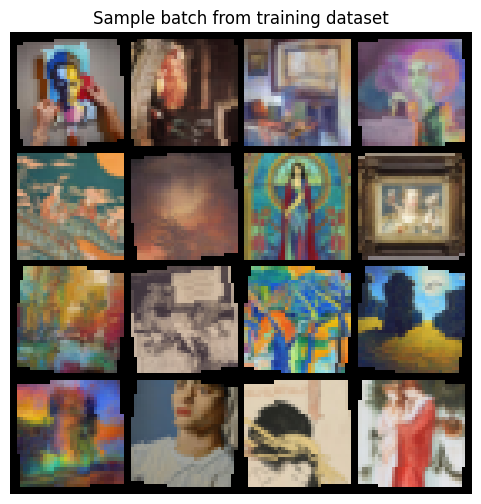

Labels: [0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1]
155015 30000


['AI', 'human']

In [6]:
# Comprobación de imágenes del dataset de entrenamiento ya transformadas
import matplotlib.pyplot as plt
import torchvision

data_iter = iter(train_loader)
images, labels = next(data_iter)

# Crea una cuadrícula automáticamente
img_grid = torchvision.utils.make_grid(images[:16], nrow=4, padding=2)
img_grid = img_grid.permute(1, 2, 0)

plt.figure(figsize=(6, 6))
plt.imshow(img_grid)
plt.title("Sample batch from training dataset")
plt.axis("off")
plt.show()

print("Labels:", labels[:16].tolist())

####     0 = AI           1 = humano

print(len(train_dataset), len(test_dataset))

train_dataset.classes

**Building the neural network**

In [7]:
# Inicialización del modelo neuronal

import torch, torch.nn as nn
import snntorch as snn
from snntorch import surrogate, spikegen

beta = 0.9
spike_grad = surrogate.fast_sigmoid() # fast sigmoid surrogate gradient
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

"""
# Estructura descontextualizada

nn.Conv2d(3, 8, 5), # 32 - 5 + 1 = 28 -> (8, 28, 28)
nn.MaxPool2d(2), # (8, 14, 14)
snn.Leaky(beta=beta, spike_grad=spike_grad, init_hidden=True), # las integrate-and-fire no cambian las dimensiones de la red
nn.Conv2d(8, 16, 5), # 14 - 5 + 1 = 10 -> (16, 10, 10)
nn.MaxPool2d(2), # (16, 5, 5)
snn.Leaky(beta=beta, spike_grad=spike_grad, init_hidden=True),
nn.Flatten(), # 16 * 5 * 5 = 400
nn.Linear(16*5*5, 10),
snn.Leaky(beta=beta, spike_grad=spike_grad, init_hidden=True, output=True)
"""

#  Initialize Convolutional SNN
class SNN_CNN(nn.Module):
    def __init__(self, num_steps=20):
        super().__init__()

        self.num_steps = num_steps

        self.conv1 = nn.Conv2d(3, 8, 5) # 32 - 5 + 1 = 28 -> (8, 28, 28)
        self.pool = nn.MaxPool2d(2) # (8, 14, 14)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=spike_grad, learn_beta=True) # las integrate-and-fire no cambian las dimensiones de la red
        
        self.conv2 = nn.Conv2d(8, 16, 5) # 14 - 5 + 1 = 10 -> (16, 10, 10)
        # Al usar la red volveremos a ejecutar maxpooling, pero ya lo haremos con la capa declarada antes por no ser redundantes
        # nn.MaxPool2d(2), # (16, 5, 5)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=spike_grad, learn_beta=True)
        self.flatten = nn.Flatten() # 16 * 5 * 5 = 400
        self.fc = nn.Linear(16*5*5, 2)
        self.lif3 = snn.Leaky(beta=beta, spike_grad=spike_grad, learn_beta=True, output=True)
    
    def forward(self, x):

        x_seq = spikegen.rate(x, num_steps=self.num_steps)

        # Inicializamos estados ocultos a t=0

        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()

        spk_rec = []
        mem_rec = []

        for step in range(self.num_steps):

            # x_temp es una función que "dispara" el valor con la entrada con una probabilidad equivalente a la intensidad que tenga
            # es decir, si un pixel tiene un valor de 0.8 de intensidad disparará con un 80% de posibilidades por cada step temporal

            # x_temp = torch.bernoulli(x) 

            x_temp = x_seq[step] # Similar al uso de bernouilli pero aprovechando el método de generación de spikes spikegen.rate()

            current = self.pool(self.conv1(x_temp)) # capa convolucional recoge la entrada x_temp y la metemos en maxpooling
            spk1, mem1 = self.lif1(current, mem1) # calculamos las spikes y la membrana de esta primera capa

            current = self.pool(self.conv2(spk1)) # introducimos la salida de la capa spiking en la segunda capa convolucional y esta a la capa maxpooling
            spk2, mem2 = self.lif2(current, mem2)

            current = self.flatten(spk2) # introducimos las salidas de la segunda capa spiking en la capa flatten para aplanar la salida
            current = self.fc(current) # introducimos la salida de la capa aplanada en la capa fully connected para obtener las categorias finales de salida

            spk3, mem3 = self.lif3(current, mem3)

            spk_rec.append(spk3)
            mem_rec.append(mem3)

        return torch.stack(spk_rec), torch.stack(mem_rec)
    
net = SNN_CNN().to(device)

**Añadimos ahora el bucle de entrenamiento**

In [8]:
# Cantidad de clases del dataset. En este caso 2: IA / NO IA
"""
num_outputs = len(train_dataset.classes)
print(len(train_dataset.classes))
"""

'\nnum_outputs = len(train_dataset.classes)\nprint(len(train_dataset.classes))\n'

In [15]:
from collections import Counter
# Como la cantidad de imágenes IA está descompensado con respecto a las humanas, vamos
# a darle más peso a los errores en la clase humana
counts = Counter(train_dataset.targets)
class_counts = torch.tensor([counts[i] for i in range(len(train_dataset.classes))], dtype=torch.float)

print("Clases:", train_dataset.classes)
print("Conteo:", class_counts)

class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * 2
class_weights = class_weights.to(device)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

Clases: ['AI', 'human']
Conteo: tensor([105015.,  50000.])


In [ ]:
# Bucle de entrenamiento

import torch.optim as optim
from codecarbon import EmissionsTracker

optimizer = optim.Adam(net.parameters(), lr=3e-4)

# Metricas por batch

loss_hist = []
test_loss_hist = []
val_accuracy_hist = []

# Metricas por epoch

epoch_loss_hist = []
epoch_test_loss_hist = []
epoch_acc_hist = []

num_epochs = 10

# Iniciamos el tracker de CodeCarbon

tracker = EmissionsTracker(
    log_level="error",
    save_to_file=True,
    output_dir="../Consumo",
    output_file="emissions_cnn+snn.csv",
    measure_power_secs=1
)
tracker.start()

for epoch in range(num_epochs):

    # TRAIN

    net.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        spk, mem = net(inputs)
        outputs = mem[-1] + 0.5 * mem.mean(dim=0) # el potencial de membrana se iguala al último potencial + la media de todos los anteriores
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Guardamos valor de train loss

        loss_hist.append(loss.item())
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        if i % 25 == 0:
            print(f"Epoch {epoch}, Iteration {i} - Loss: {running_loss/(i+1):.4f} Accuracy: {100*correct/total:.2f}%")

    # Guardamos valores de loss y accuracy por epoch del train
    epoch_loss_hist.append(running_loss / len(train_loader))
    epoch_acc_hist.append(100 * correct / total)

    # TEST

    net.eval()
    test_loss = 0.0
    correct_test = 0
    total_test = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            spk, mem = net(inputs)
            outputs = mem[-1] + 0.5 * mem.mean(dim=0)
            loss = criterion(outputs, labels)


            # Guardamos valor de las métricas de todo el test por batch
            test_loss_hist.append(loss.item())
            batch_correct = (torch.max(outputs.data, 1)[1] == labels).sum().item()
            batch_acc = 100 * batch_correct / labels.size(0)
            val_accuracy_hist.append(batch_acc)

            test_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    avg_test_loss = test_loss / len(test_loader)
    test_accuracy = 100 * correct_test / total_test

    # Guardamos valor de loss del test por epoch
    epoch_test_loss_hist.append(avg_test_loss)


    print(f"[TEST] Epoch {epoch} - Loss: {avg_test_loss:.4f} Acc: {test_accuracy:.2f}%")

# Detenemos el tracker de CodeCarbon

emissions = tracker.stop()
print(f"Emisiones de CO₂ (kg): {emissions}")

print("Entrenamiento terminado")


[codecarbon WARNING @ 21:13:21] Multiple instances of codecarbon are allowed to run at the same time.


Epoch 0, Iteration 0 - Loss: 1.4438 Accuracy: 67.19%
Epoch 0, Iteration 25 - Loss: 0.7297 Accuracy: 38.64%
Epoch 0, Iteration 50 - Loss: 0.6791 Accuracy: 36.24%
Epoch 0, Iteration 75 - Loss: 0.6623 Accuracy: 34.99%
Epoch 0, Iteration 100 - Loss: 0.6515 Accuracy: 34.58%
Epoch 0, Iteration 125 - Loss: 0.6443 Accuracy: 34.67%
Epoch 0, Iteration 150 - Loss: 0.6356 Accuracy: 34.89%
Epoch 0, Iteration 175 - Loss: 0.6258 Accuracy: 35.50%
Epoch 0, Iteration 200 - Loss: 0.6213 Accuracy: 36.24%
Epoch 0, Iteration 225 - Loss: 0.6164 Accuracy: 36.88%
Epoch 0, Iteration 250 - Loss: 0.6083 Accuracy: 37.66%
Epoch 0, Iteration 275 - Loss: 0.6019 Accuracy: 38.42%
Epoch 0, Iteration 300 - Loss: 0.5955 Accuracy: 39.52%
Epoch 0, Iteration 325 - Loss: 0.5894 Accuracy: 40.61%
Epoch 0, Iteration 350 - Loss: 0.5823 Accuracy: 41.64%
Epoch 0, Iteration 375 - Loss: 0.5765 Accuracy: 42.45%
Epoch 0, Iteration 400 - Loss: 0.5712 Accuracy: 43.15%
Epoch 0, Iteration 425 - Loss: 0.5665 Accuracy: 43.89%
Epoch 0, Iterat

In [10]:
# Guardamos checkpoint al final de cada epoch
torch.save({
    'epoch': epoch,
    'model_state_dict': net.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss_hist': loss_hist,
    'test_loss_hist': test_loss_hist,
    'val_accuracy_hist': val_accuracy_hist,
    'epoch_loss_hist': epoch_loss_hist,
    'epoch_test_loss_hist': epoch_test_loss_hist,
    'epoch_acc_hist': epoch_acc_hist,
}, '../Modelos_Guardados/checkpoint_cnn+snn.pth')

In [ ]:
import torch.optim as optim
from codecarbon import EmissionsTracker

num_epochs = 4
counter = 0

optimizer = optim.Adam(net.parameters(), lr=3e-4)

def accuracy(mem, targets):
    preds = mem.argmax(dim=1)
    return (preds == targets).float().mean().item() * 100


# Cargamos el checkpoint para reanudar el entrenamiento

checkpoint = torch.load('../Modelos_Guardados/checkpoint_cnn+snn.pth', map_location=device)

net.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

loss_hist = checkpoint['loss_hist']
test_loss_hist = checkpoint['test_loss_hist']
val_accuracy_hist = checkpoint['val_accuracy_hist']
epoch_loss_hist = checkpoint['epoch_loss_hist']
epoch_test_loss_hist = checkpoint['epoch_test_loss_hist']
epoch_acc_hist = checkpoint['epoch_acc_hist']

start_epoch = checkpoint['epoch'] + 1

def train():
    global counter

    tracker = EmissionsTracker(
        log_level="error",
        save_to_file=True,
        output_dir="../Consumo",
        output_file="emissions_cnn+snn.csv",
        measure_power_secs=1
    )
    tracker.start()

    for epoch in range(start_epoch, num_epochs):

        # TRAIN

        net.train()
        running_loss = 0.0
        correct = 0
        total = 0
        num_batches = 0

        for i, (data, targets) in enumerate(train_loader):

            data = data.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()

            spk_rec, mem_rec = net(data)
            num_steps = mem_rec.size(0)

            loss_val = 0
            for step in range(num_steps):
                loss_val = loss_val + criterion(mem_rec[step], targets)

            loss_val = loss_val / num_steps

            loss_val.backward()
            optimizer.step()

            loss_hist.append(loss_val.item())

            running_loss += loss_val.item()
            _, predicted = torch.max(mem_rec[-1], 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
            num_batches += 1

            if i % 25 == 0:
                print(f"Epoch {epoch}, Iteration {i} - Loss: {running_loss/(i+1):.4f} Accuracy: {100*correct/total:.2f}%")

        epoch_loss_hist.append(running_loss / num_batches)
        epoch_acc_hist.append(100 * correct / total)

        # TEST

        net.eval()
        test_loss = 0.0
        correct_test = 0
        total_test = 0
        num_test_batches = 0

        with torch.no_grad():

            for test_data, test_targets in test_loader:

                test_data = test_data.to(device)
                test_targets = test_targets.to(device)

                test_spk, test_mem = net(test_data)

                test_loss_val = 0
                for step in range(num_steps):
                    test_loss_val += criterion(test_mem[step], test_targets)

                test_loss_val = test_loss_val / num_steps

                test_loss_hist.append(test_loss_val.item())

                test_loss += test_loss_val.item()

                val_acc = accuracy(test_mem[-1], test_targets)
                val_accuracy_hist.append(val_acc)

                _, predicted_test = torch.max(test_mem[-1], 1)
                total_test += test_targets.size(0)
                correct_test += (predicted_test == test_targets).sum().item()

                num_test_batches += 1
                counter += 1

        avg_test_loss = test_loss / num_test_batches
        test_accuracy = 100 * correct_test / total_test

        epoch_test_loss_hist.append(avg_test_loss)
        epoch_acc_hist.append(test_accuracy)

        print(f"[TEST] Epoch {epoch} - Loss: {avg_test_loss:.4f} Acc: {test_accuracy:.2f}%")

    emissions = tracker.stop()
    print(f"Emisiones de CO₂ (kg): {emissions}")


train()

import pandas as pd
df = pd.read_csv("emissions_cnn+snn.csv")
total_emissions = df['emissions'].sum()
print(f"Emisiones totales acumuladas (incluyendo esta sesión): {total_emissions} kg CO2")

[codecarbon WARNING @ 19:46:08] Multiple instances of codecarbon are allowed to run at the same time.


Epoch 2, Iteration 0 - Loss: 0.5761 Accuracy: 76.56%
Epoch 2, Iteration 25 - Loss: 0.4792 Accuracy: 70.61%
Epoch 2, Iteration 50 - Loss: 0.4463 Accuracy: 73.77%
Epoch 2, Iteration 75 - Loss: 0.4396 Accuracy: 74.69%
Epoch 2, Iteration 100 - Loss: 0.4296 Accuracy: 75.63%
Epoch 2, Iteration 125 - Loss: 0.4247 Accuracy: 75.89%
Epoch 2, Iteration 150 - Loss: 0.4207 Accuracy: 76.07%
Epoch 2, Iteration 175 - Loss: 0.4189 Accuracy: 76.09%
Epoch 2, Iteration 200 - Loss: 0.4174 Accuracy: 76.31%
Epoch 2, Iteration 225 - Loss: 0.4149 Accuracy: 76.54%
Epoch 2, Iteration 250 - Loss: 0.4145 Accuracy: 76.66%
Epoch 2, Iteration 275 - Loss: 0.4133 Accuracy: 76.63%
Epoch 2, Iteration 300 - Loss: 0.4116 Accuracy: 76.92%
Epoch 2, Iteration 325 - Loss: 0.4104 Accuracy: 76.74%
Epoch 2, Iteration 350 - Loss: 0.4094 Accuracy: 76.80%
Epoch 2, Iteration 375 - Loss: 0.4095 Accuracy: 76.73%
Epoch 2, Iteration 400 - Loss: 0.4090 Accuracy: 76.86%
Epoch 2, Iteration 425 - Loss: 0.4083 Accuracy: 76.79%
Epoch 2, Iterat

**Graficando los valores obtenidos**

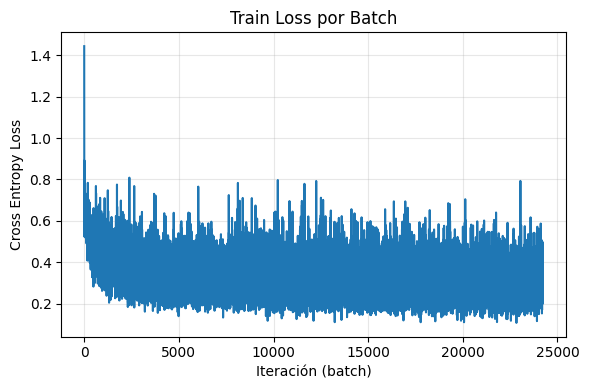

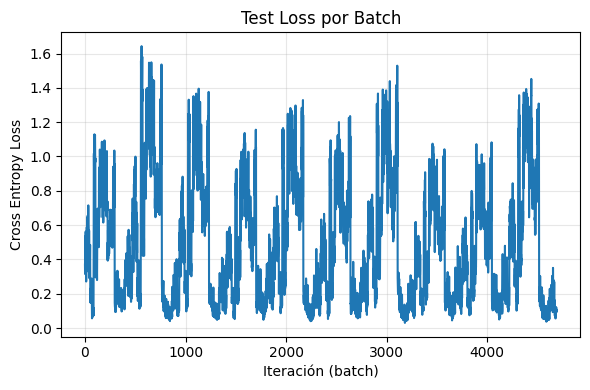

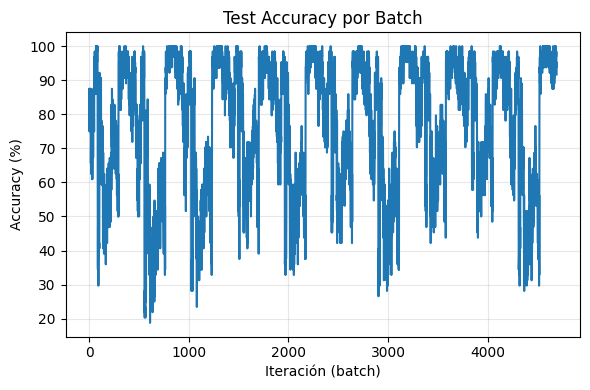

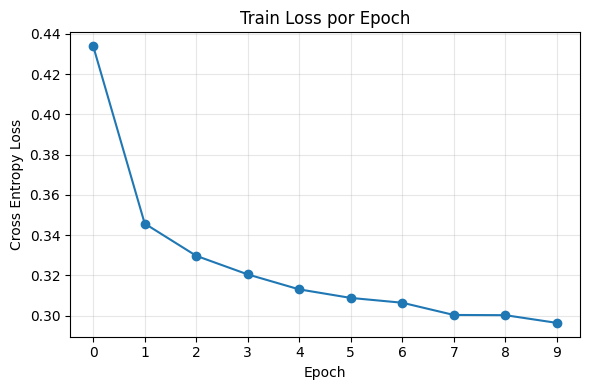

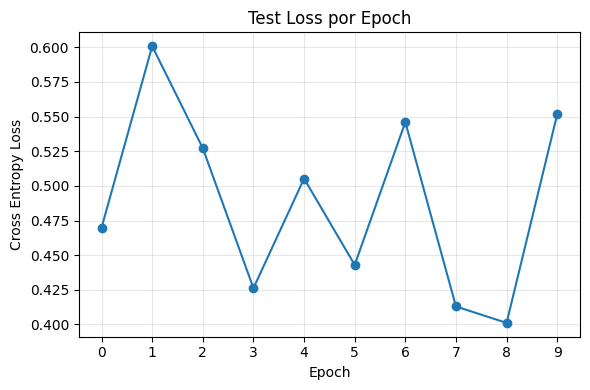

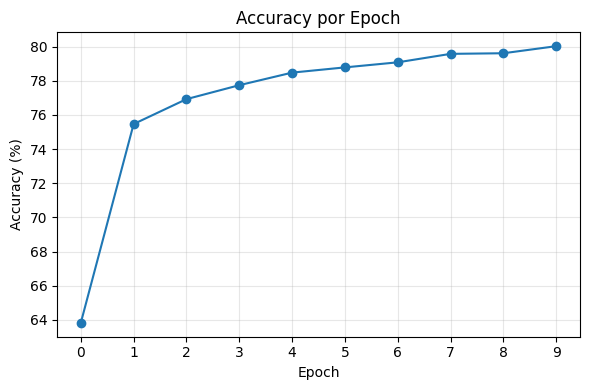

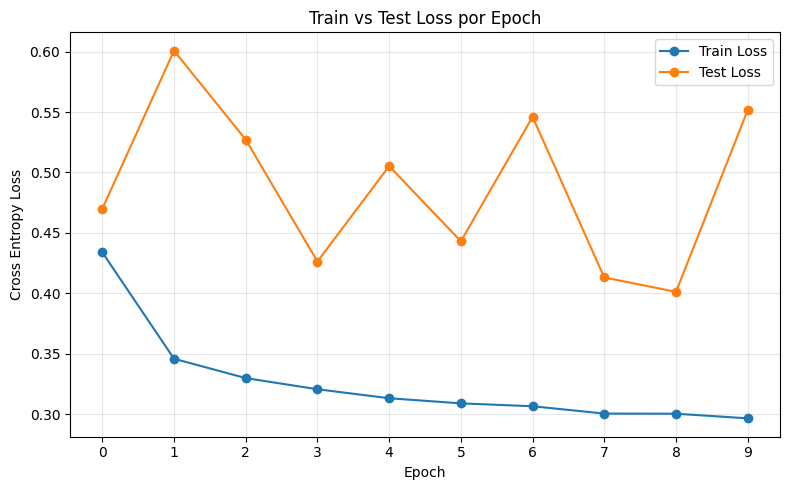

In [14]:
import matplotlib.pyplot as plt

# GRÁFICAS NIVEL BATCH

import matplotlib.pyplot as plt

# Train Loss por batch
plt.figure(figsize=(6, 4))
plt.plot(loss_hist)
plt.title("Train Loss por Batch")
plt.xlabel("Iteración (batch)")
plt.ylabel("Cross Entropy Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../Graficas/CNN+SNN/train_loss_batch.png", dpi=150)
plt.show()


# Test Loss por batch
plt.figure(figsize=(6, 4))
plt.plot(test_loss_hist)
plt.title("Test Loss por Batch")
plt.xlabel("Iteración (batch)")
plt.ylabel("Cross Entropy Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../Graficas/CNN+SNN/test_loss_batch.png", dpi=150)
plt.show()


# Test Accuracy por batch
plt.figure(figsize=(6, 4))
plt.plot(val_accuracy_hist)
plt.title("Test Accuracy por Batch")
plt.xlabel("Iteración (batch)")
plt.ylabel("Accuracy (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../Graficas/CNN+SNN/test_accuracy_batch.png", dpi=150)
plt.show()

# GRÁFICAS NIVEL EPOCH

epochs_range = range(len(epoch_loss_hist))

# Train Loss por epoch
plt.figure(figsize=(6, 4))
plt.plot(epochs_range, epoch_loss_hist, marker='o')
plt.title("Train Loss por Epoch")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.xticks(epochs_range)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../Graficas/CNN+SNN/train_loss_epoch.png", dpi=150)
plt.show()


# Test Loss por epoch
plt.figure(figsize=(6, 4))
plt.plot(epochs_range, epoch_test_loss_hist, marker='o')
plt.title("Test Loss por Epoch")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.xticks(epochs_range)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../Graficas/CNN+SNN/test_loss_epoch.png", dpi=150)
plt.show()


# Accuracy por epoch
epochs_range_acc = range(len(epoch_acc_hist))

plt.figure(figsize=(6, 4))
plt.plot(epochs_range_acc, epoch_acc_hist, marker='o')
plt.title("Accuracy por Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.xticks(epochs_range_acc)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../Graficas/CNN+SNN/accuracy_epoch.png", dpi=150)
plt.show()

# COMPARATIVA TRAIN vs TEST LOSS POR EPOCH (superpuesto)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, epoch_loss_hist, marker='o', label="Train Loss")
plt.plot(epochs_range, epoch_test_loss_hist, marker='o', label="Test Loss")
plt.title("Train vs Test Loss por Epoch")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.xticks(epochs_range)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../Graficas/CNN+SNN/train_vs_test_loss.png", dpi=150)
plt.show()

In [ ]:
from PIL import Image
from torchvision import transforms

net.eval()

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])

# Carga y preprocesa la imagen
img_path = "/home/rootcgb/Documentos/AI-Artbench/evalPropio/van.jpg"  # pon aquí la ruta real
img = Image.open(img_path).convert('RGB')
img = transform(img).unsqueeze(0).to(device)  # añadir batch dim y pasar a dispositivo

with torch.no_grad():
    outputs = net(img)
    _, predicted_class = torch.max(outputs, 1)

if (predicted_class.item() == 0):
    salida = "IA"
else:
    salida = "Humano"
print(f"La imagen es de la clase: {salida}")

NameError: name 'net' is not defined

In [ ]:
# Evaluando 10 imagenes aleatorias del test

#predictions = net.predict(test_dataset)
#predictions
def predict_dataset(model, test_loader, device):
    model.eval()
    all_predictions = []
    all_targets = []
    
    with torch.no_grad():
        for data, targets in test_loader:
            data = data.to(device)
            
            # Forward pass
            spk_rec, mem_rec = model(data)
            
            # Rate coding: suma de spikes en el tiempo
            spike_counts = spk_rec.sum(dim=0)  # (batch_size, num_classes)
            
            # Predicción: neurona con más spikes
            _, predicted = spike_counts.max(1)
            
            all_predictions.append(predicted.cpu())
            all_targets.append(targets)
    
    # Concatenar todas las predicciones
    predictions = torch.cat(all_predictions)
    targets = torch.cat(all_targets)
    
    return predictions, targets

# USO:
predictions, true_labels = predict_dataset(net, test_loader, device)
print(f"Predicciones: {predictions[:10]}")
print(f"Labels reales: {true_labels[:10]}")

Predicciones: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
Labels reales: tensor([0, 0, 0, 0, 0, 0, 1, 1, 1, 0])
